In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings
warnings.filterwarnings('ignore', category = FutureWarning)

# Sub-task 1: Unsupervised Learning 
### Using Python, apply k-means to partition the data set into three clusters. Plot a graph of the resulting clusters. Your (fictional) colleague claims to have done the above multiple times. They claim that in their experience, k-means always converges quickly on this dataset and that the graphs that they get after each run of the algorithm (with different random seeds) show very similar clusters. They say that this shows that the three clusters found with k-means are the best possible clusters within this dataset. Do you agree with your colleague? Justify your answer based on your graph, and on your understanding of the k-means algorithm.

In [104]:
df1 = pd.read_csv(r'cluster.csv', header = None, sep = ',')
df1.columns = ['Point1', 'Point2']
df1 = df1.astype('Float32')
df1.describe()

,Point1,Point2
count,500.0,500.0
mean,3.943291,-0.997142
std,2.395397,1.704309
min,-1.1647,-4.9663
25%,1.940225,-1.241425
50%,3.0418,-0.65717
75%,6.58395,-0.0282
max,7.5723,1.5068


In [105]:
# K-Means is scale-sensitive as it uses Euclidean distance to compute. High range or variance features control the clustering. In our dataset:
# Point1: Range = (-1.1647, 7.5723), Variance = (2.395397)^2 | Point2: Range = (-4.9663, 1.5068), Variance = (1.704309)^2
# Due to the differences in ranges and variances, scaling is required so that there is an equal contribution from all features.

df = df1.copy()
#df_scaled = (df - df.min()) / (df.max() - df.min())
#df_scaled.describe()
sc = StandardScaler()
df_scaled = sc.fit_transform(df)

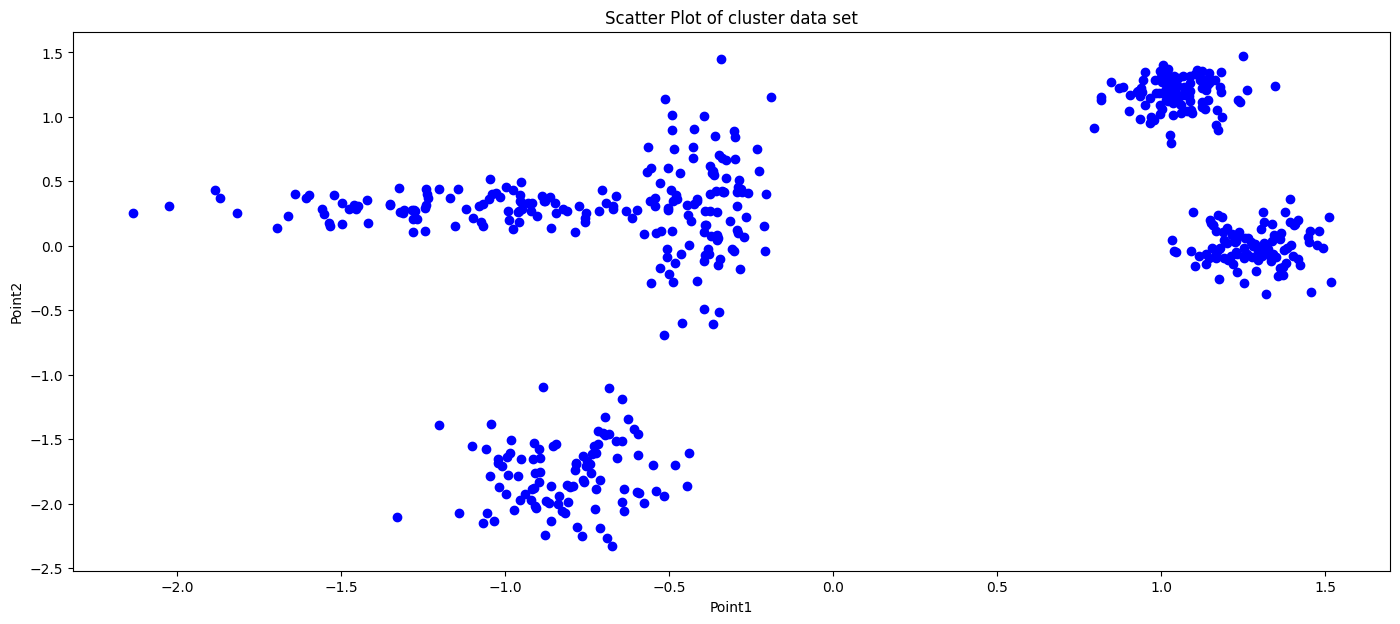

In [106]:
# Sometimes, by looking at the Scatter plot, we can gain a better understanding of the data and potentially number of the clusters.
# Especially for this dataset, which has 500 data points and two variables that can be easily plotted in a 2D plane. 
# However, if the clusters were spherical and overlapping, it would be more challenging to estimate the number of clusters visually.
plt.figure(figsize = (17, 7))
plt.scatter(df_scaled[:,0], df_scaled[:,1], c = 'blue')
plt.xlabel('Point1')
plt.ylabel('Point2')
plt.title('Scatter Plot of cluster data set')
plt.show()

In [107]:
def clustering(df, n_clusters = 3):
    '''
    This function returns the centroids and labels and pass them for next function to plot the data points + centroids.
    ----------------------------------------------------------
    df: The DataFrame containing the data points.
    n_clusters: The number of clusters to create. Default is set to 3.
    '''
    kmeans = KMeans(n_clusters = n_clusters, random_state = 92)

    labels = kmeans.fit_predict(df_scaled)
    centroids = kmeans.cluster_centers_
        
    return centroids, labels

In [108]:
def cluster_visualization(df, centroids, labels, n_clusters = 3):
    '''
    This function visualizes the clustering results by plotting each cluster and its centroids.
    -------------------------------------------------------------------
    df: The DataFrame containing the data points.
    centroids: The centroids of the clusters.
    labels: The cluster labels for each data point.
    n_clusters: The number of clusters to visualize. Default is set to 3.
    '''
    
    plt.figure(figsize=(10, 5))

    for label in range(n_clusters):
        plt.scatter(df[labels == label, 0], df[labels == label, 1],
                     label=f'Cluster {label + 1}') # plot datapoints for each cluster

    plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=25, alpha=0.8, label='Centroids', marker='x') # plot the centroids

    plt.xlabel('Point1')
    plt.ylabel('Point2')
    plt.title(f'{n_clusters} Clusters of data set, Silhouette Score : {np.round(silhouette_score(df, labels), 4)}')
    plt.legend()
    plt.show()

In [109]:
silo_score_avg = []

for num in range(2, 11):  # for each number of cluster, take random state from 1 to 100 then average the silhouette score and plot them
    scores = []
    for rand in np.arange(1, 100):
        kmeans = KMeans(n_clusters = num, random_state = rand, n_init = num)
        kmeans.fit_predict(df_scaled)
        scores.append(silhouette_score(df_scaled, kmeans.labels_))
    silo_score_avg.append(np.mean(scores))
        

silhouette_avg = sum(silo_score_avg) / len(silo_score_avg)

print("The overal average silhouette_score is:", np.round(silhouette_avg, 4))
for i, avg in enumerate(silo_score_avg): # We can comment this part, beacaues in the next steps we will be ploting it. 
    print(f"Cluster {i + 2}: Silhouette Score = {avg:.4f}") 

The overal average silhouette_score is: 0.639
Cluster 2: Silhouette Score = 0.5494
Cluster 3: Silhouette Score = 0.6817
Cluster 4: Silhouette Score = 0.7442
Cluster 5: Silhouette Score = 0.6876
Cluster 6: Silhouette Score = 0.6682
Cluster 7: Silhouette Score = 0.6697
Cluster 8: Silhouette Score = 0.5992
Cluster 9: Silhouette Score = 0.5868
Cluster 10: Silhouette Score = 0.5642


In [110]:
elbow_score_avg = []  # List to store WCSS values
cluster_range = range(2, 11)  # Range of clusters and n_init set to range of (2 to 10)

for num in cluster_range:
    elbow_score = []
    for rand in np.arange(1, 100):
        kmeans = KMeans(n_clusters = num, random_state = rand, n_init = num)
        kmeans.fit(df1)
        elbow_score.append(kmeans.inertia_)
    elbow_score_avg.append(np.mean(elbow_score))

elbow_avg = np.mean(elbow_score_avg)

print("The overal average elbow_score is:", np.round(elbow_avg, 4)) # The elbow score keeps getting smaller as the number of clusters increases.
for i, avg in enumerate(elbow_score_avg): # Like previous part, we can comment this part, beacaues in the next step we will be ploting it. 
    print(f"Cluster {i + 2}: Elbow Score = {avg:.4f}")

The overal average elbow_score is: 325.3614
Cluster 2: Elbow Score = 1389.3102
Cluster 3: Elbow Score = 556.3177
Cluster 4: Elbow Score = 338.7842
Cluster 5: Elbow Score = 162.6626
Cluster 6: Elbow Score = 132.5513
Cluster 7: Elbow Score = 103.7126
Cluster 8: Elbow Score = 90.0229
Cluster 9: Elbow Score = 81.5186
Cluster 10: Elbow Score = 73.3722


# Ploting the results:

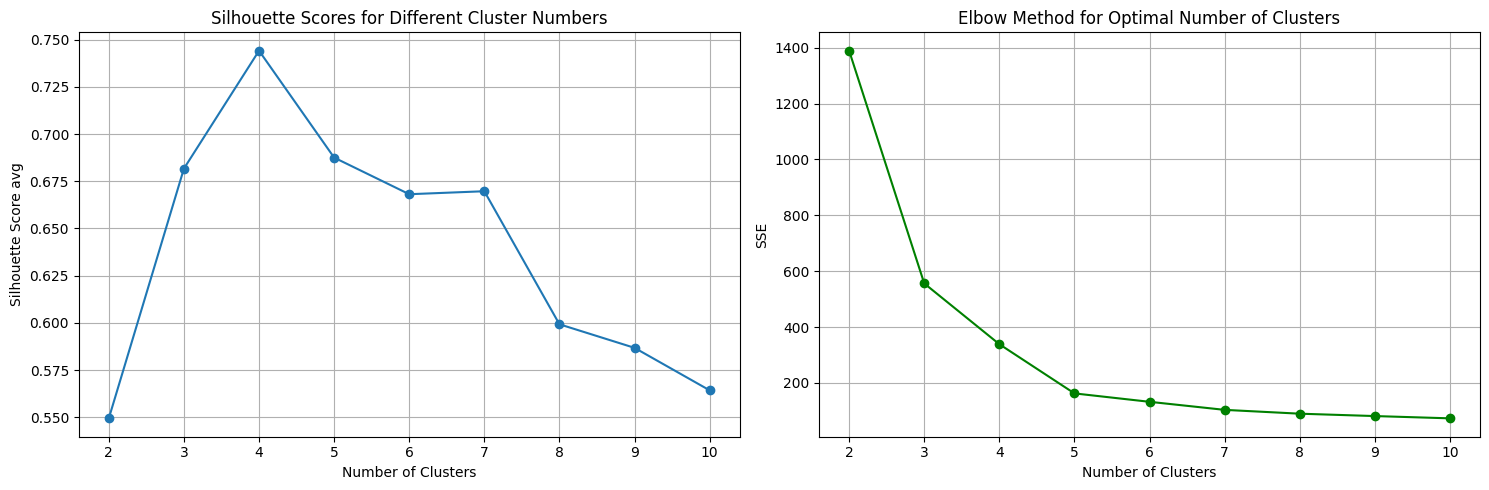

In [111]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(cluster_range, silo_score_avg, marker='o')
ax[0].set_xlabel('Number of Clusters')
ax[0].set_ylabel('Silhouette Score avg')
ax[0].set_title('Silhouette Scores for Different Cluster Numbers')
ax[0].grid()

ax[1].plot(cluster_range, elbow_score_avg, marker='o', color='g')
ax[1].set_xlabel('Number of Clusters')
ax[1].set_ylabel('SSE')
ax[1].set_title('Elbow Method for Optimal Number of Clusters')
ax[1].grid()

plt.tight_layout()
plt.show()

For 3 clusters:
[[ 1.16445111  0.58888235]
 [-0.75770689  0.29895845]
 [-0.81348844 -1.7756816 ]]


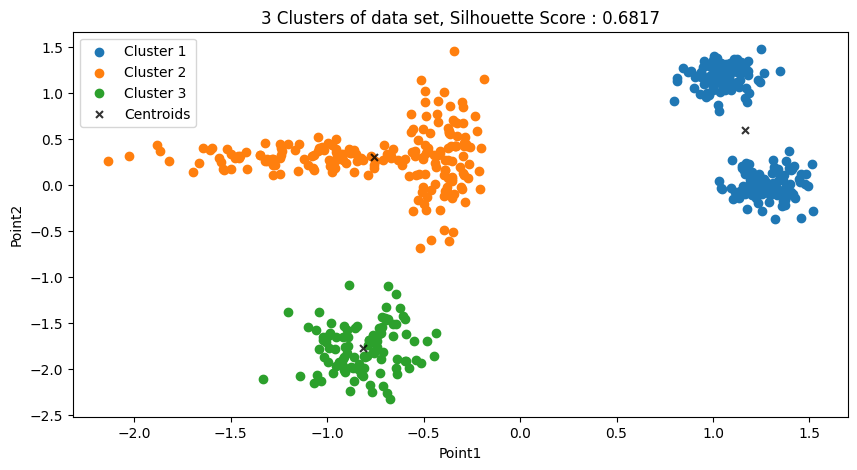

------------------------------------------------------------------------------------------------------------------
For 4 clusters:
[[ 1.27812621 -0.00307656]
 [-0.75770689  0.29895845]
 [-0.81348844 -1.7756816 ]
 [ 1.05077602  1.18084125]]


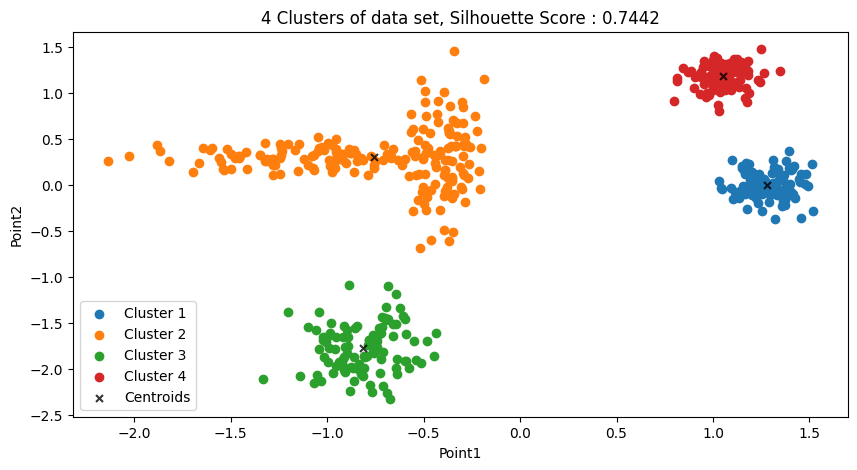

------------------------------------------------------------------------------------------------------------------
For 5 clusters:
[[ 1.27812621 -0.00307656]
 [-1.24237219  0.30237449]
 [-0.81348844 -1.7756816 ]
 [ 1.05077602  1.18084125]
 [-0.44127252  0.29672814]]


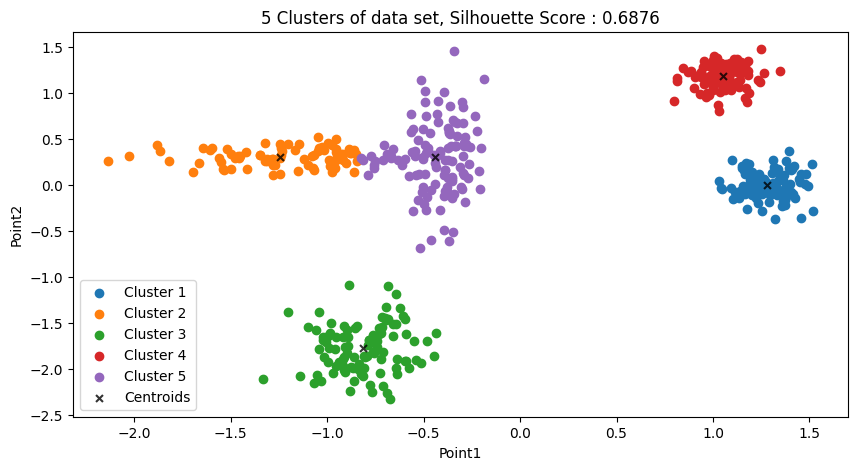

------------------------------------------------------------------------------------------------------------------


In [112]:
for k in [3, 4, 5]:
    print(f'For {k} clusters:')
    centroids, labels = clustering(df_scaled, n_clusters = k)
    print(centroids)
    cluster_visualization(df_scaled, centroids, labels, n_clusters = k)
    print(19 * '------')

For n_clusters = 2 The average silhouette_score is : 0.5509
For n_clusters = 3 The average silhouette_score is : 0.6817
For n_clusters = 4 The average silhouette_score is : 0.7442
For n_clusters = 5 The average silhouette_score is : 0.6876
For n_clusters = 6 The average silhouette_score is : 0.6061


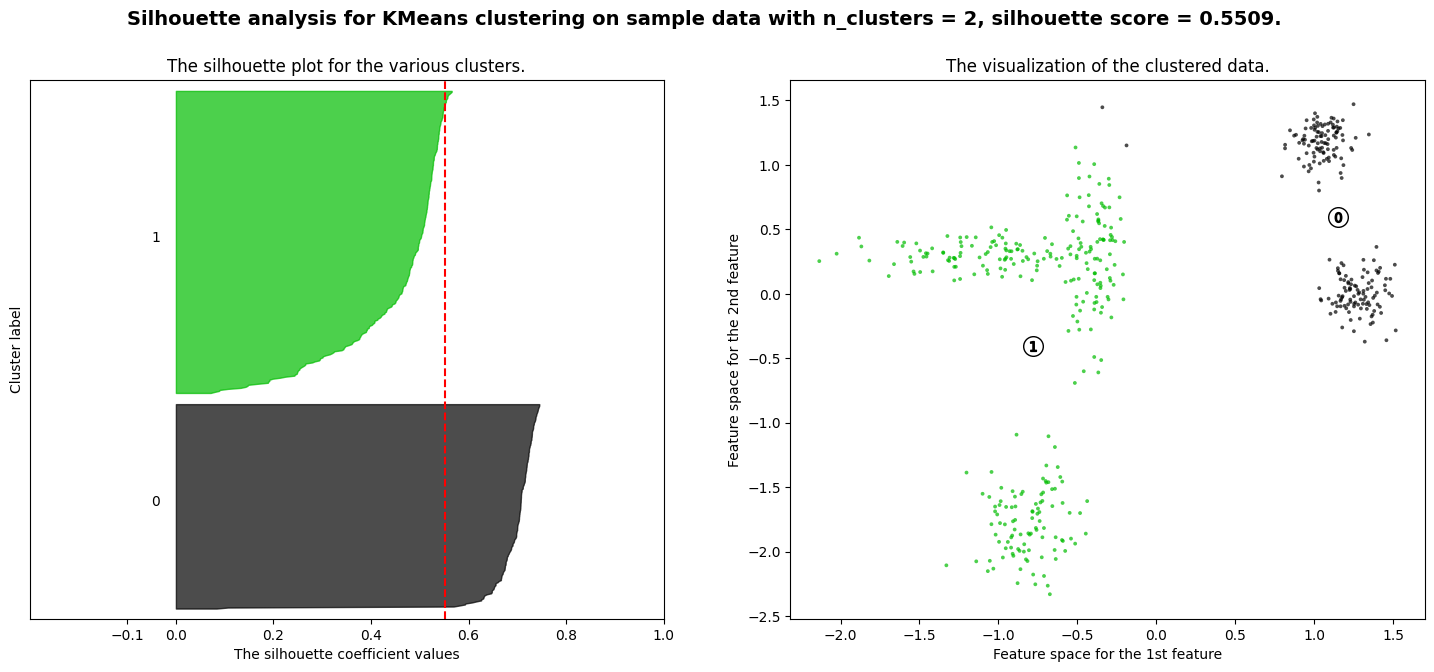

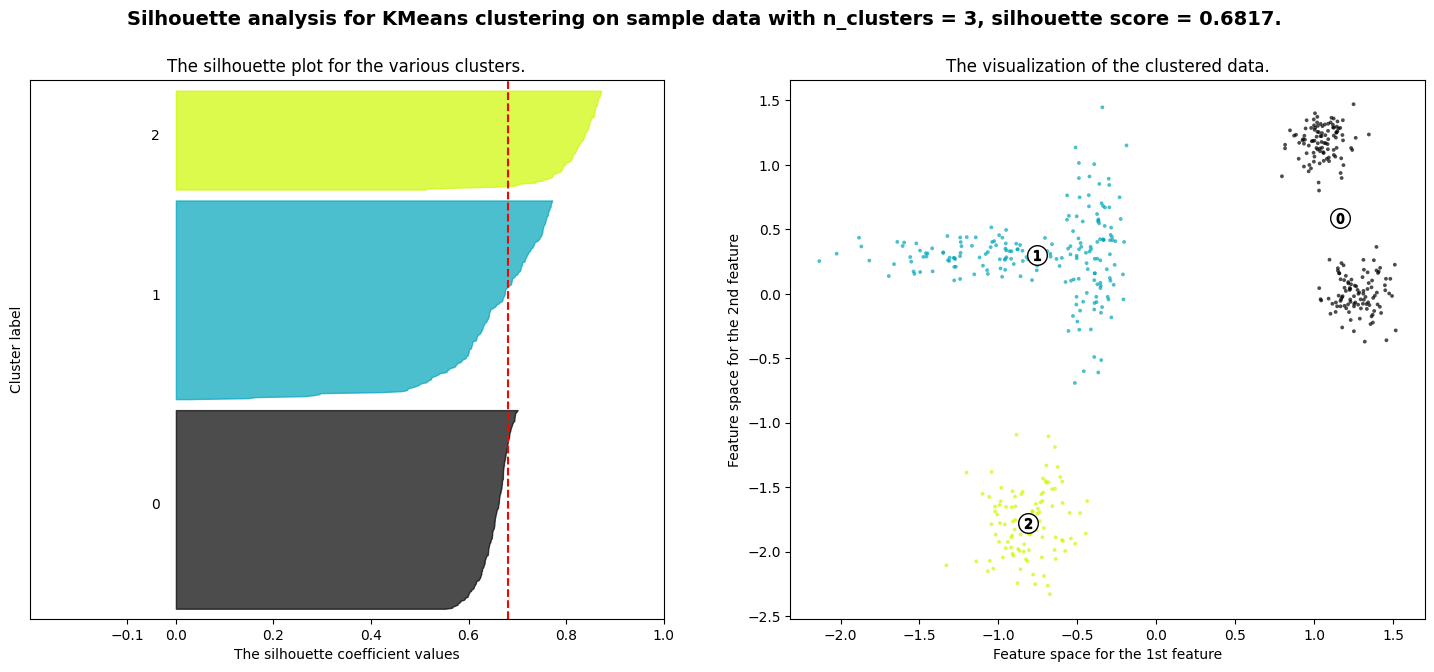

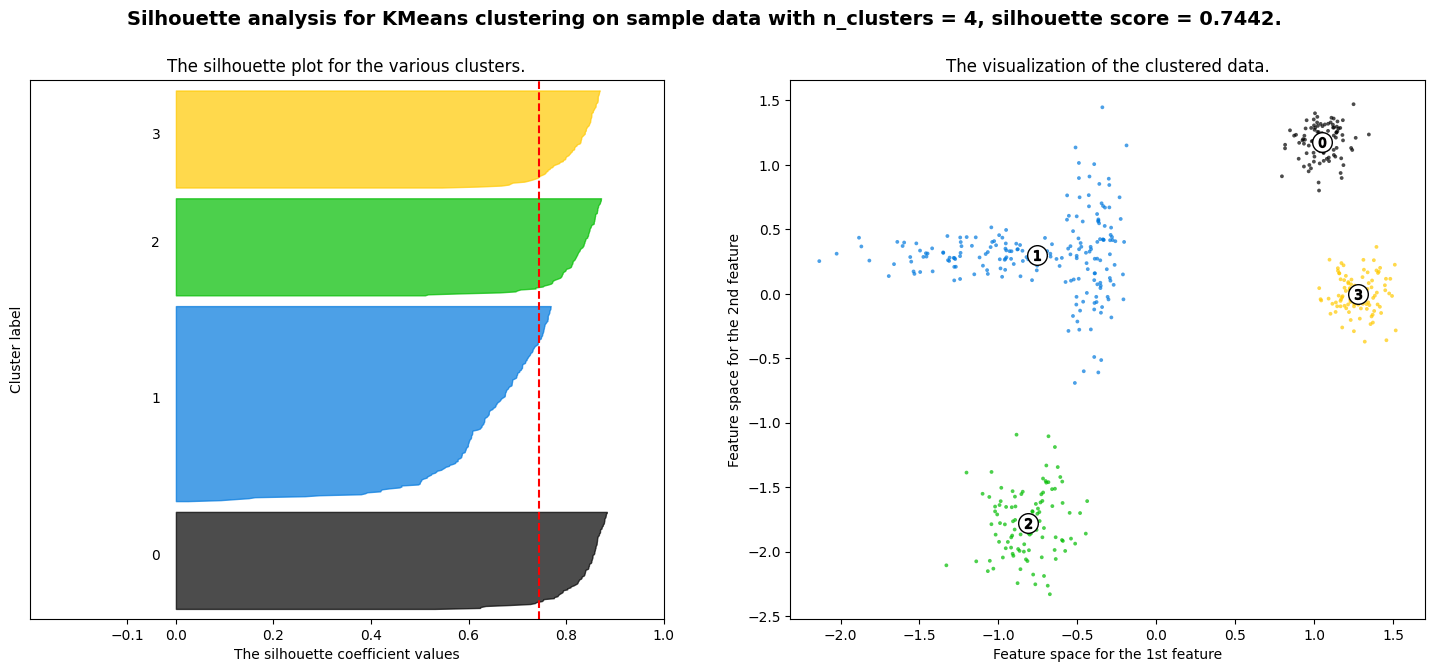

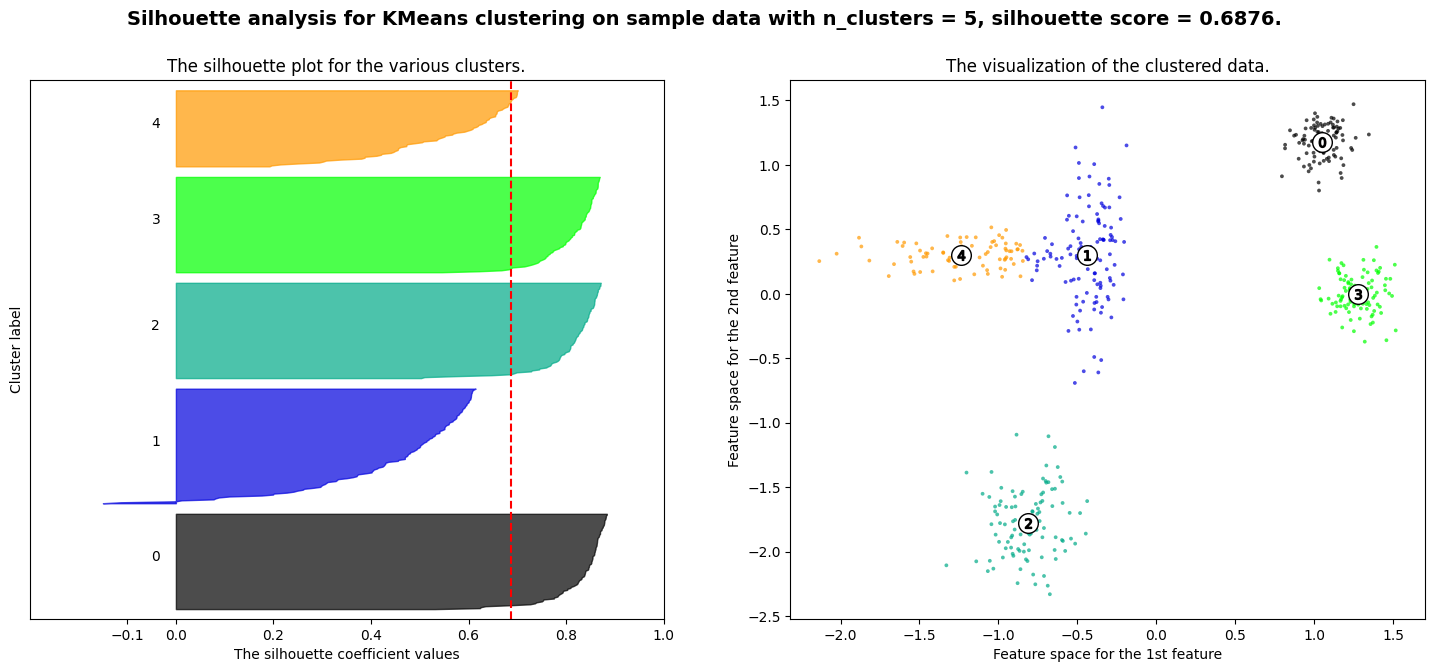

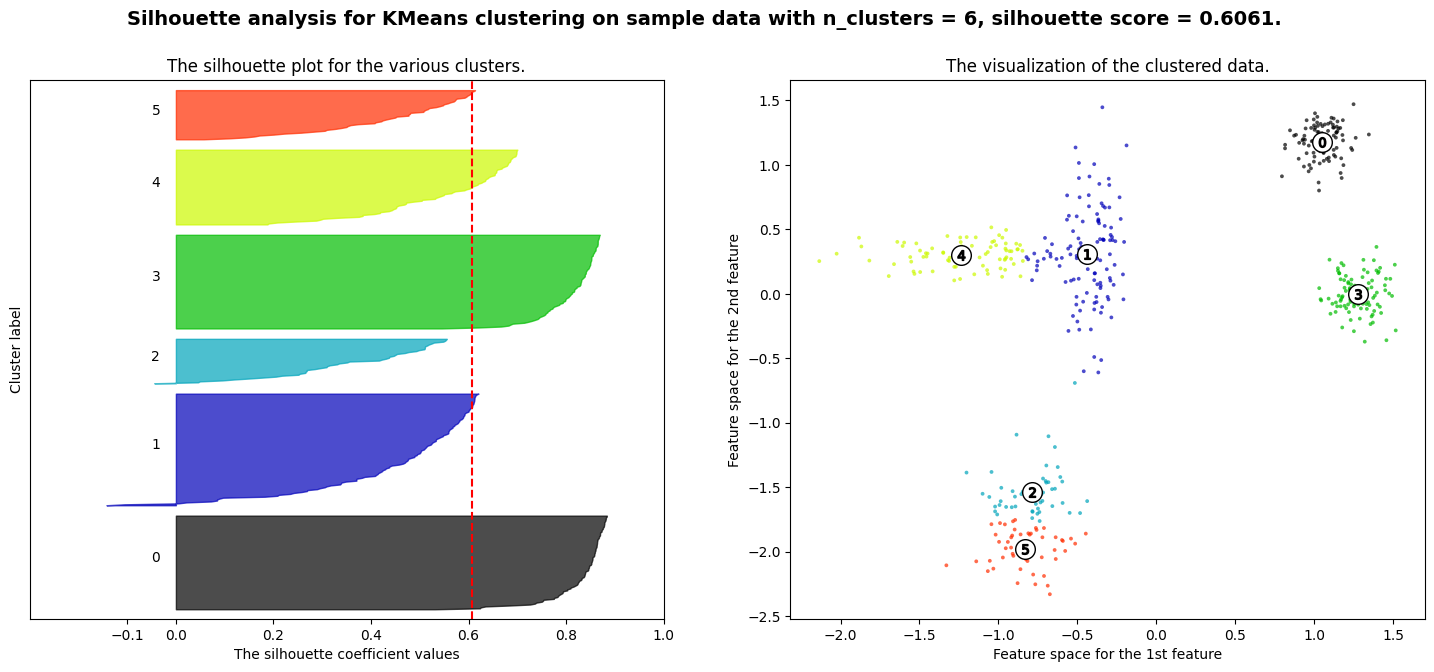

In [115]:
# This part of code is from sklearn documentation, however, some modification are made to fit data and adjust the plot.
range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    ax1.set_xlim([-0.3, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(df_scaled) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    clusterer = KMeans(n_clusters=n_clusters, random_state = 10)
    cluster_labels = clusterer.fit_predict(df_scaled)
    

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed clusters
    silhouette_avg = silhouette_score(df_scaled, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        np.round(silhouette_avg, 4),
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(df_scaled, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x = silhouette_avg, color = "red", linestyle = "--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        df_scaled[:, 0], df_scaled[:, 1], marker = ".", s = 30, lw = 0, alpha = 0.7, c = colors, edgecolor = "k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker = "o",
        c = "white",
        alpha = 1,
        s = 200,
        edgecolor = "k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker = "$%d$" % i, alpha = 1, s = 50, edgecolor = "k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        f"Silhouette analysis for KMeans clustering on sample data with n_clusters = {n_clusters}, silhouette score = {np.round(silhouette_avg, 4)}.",
        fontsize=14,
        fontweight="bold",
    )

plt.show()

# Clustering Analysis Summary

## Key Findings

- **Challenging the Claim:**  
  The statement that _"3 clusters are always best"_ is **not supported** by the analysis.

- **Random Seed Sensitivity:**  
  Even with `k-means++` initialization, clustering results **vary across different random seeds** (tested with 99 seeds per cluster count).

- **Optimal Number of Clusters:**  
  - **4 or 5 clusters** yield higher average silhouette scores and better-defined groupings compared to 3 clusters.
  - For **5 clusters**, some points in cluster 1 are not properly assigned, indicating possible overlaps or limitations in centroid placement.

## Computational Considerations

- **Robustness vs. Efficiency:**  
  Running K-means with multiple seeds (`n_init` from 2 to 10, 99 seeds each) gives a more robust view but is **computationally expensive**.

- **Alternative Algorithms:**  
  - **Density-based clustering (DBSCAN, HDBSCAN):** These methods do not rely on initial centroids or random seeds and may handle noise/outliers better.
  - On the other hand if the data has a meaningful hierarchy, **Hierarchical clustering** would be a good choice.

---

**Reference**:  
1- Arthur, D., & Vassilvitskii, S. (2007). *k-means++: The advantages of careful seeding*. [PDF Link](https://theory.stanford.edu/~sergei/papers/kMeansPP-soda.pdf)

2- Ester, M., Kriegel, H.-P., Sander, J., & Xu, X. (1996). *A density-based algorithm for discovering clusters in large spatial databases with noise*. [PDF Link](https://www.aaai.org/Papers/KDD/1996/KDD96-037.pdf)

3- Leland McInnes, John Healy, and Steve Astels hdbscan: Hierarchical density based clustering [Web page](https://www.researchgate.net/publication/315508524_hdbscan_Hierarchical_density_based_clustering)
